#### Libraries Import

In [1]:
#Data manipulation
import pandas as pd
import numpy as np

#Dataset Loading
from pathlib import Path

#for regex
import re

#Encoder (Categorical to Numeric)
from sklearn.preprocessing import LabelEncoder


import gc
import os

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Evaluation
from sklearn.metrics import (classification_report, roc_auc_score, 
            f1_score,confusion_matrix,
            ConfusionMatrixDisplay, 
            roc_curve, 
            auc, 
            precision_recall_curve, 
            average_precision_score)

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns


##### Dataset Source

Loading datasets from the sources in chunks to avoid memory crash.

Cross Dataset Generalization
1. Train dataset : CICIDS2017 from Kaggle (chethuhn/network-intrusion-dataset)
2. Test dataset1: CSE-CIC-IDS2018 from Kaggle (solarmainframe/ids-intrusion-csv)
3. Test dataset1: UNSW-NB15 (https://cicresearch.ca//CICDataset/CIC-UNSW/)

##### Loading the datasets

In [2]:
#Column Normalization
def clean_column_names(df):
    """
    Standardize column names across datasets.
    1. Strip whitespace.
    2. Convert to lowercase.
    3. Replace:
        space -> _
        /     -> _
        -     -> _
        .     -> _
    4. Remove duplicate columns.
    5. Remove double underscores.

    Example:
    --------
    ' Flow Duration ' -> flow_duration
    'Dst-Port'        -> dst_port
    """

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )

    df.columns = df.columns.str.replace("__", "_", regex=False)

    df = df.loc[:, ~df.columns.duplicated()]

    return df

#Optimize memory
def optimize_dtypes(df):
    LABEL_COL = "label"
    SOURCE_COL = "source_file"

    # Handle label safely
    if LABEL_COL in df.columns:
        df[LABEL_COL] = df[LABEL_COL].astype("category")

    # Convert everything else to numeric
    exclude = {LABEL_COL, SOURCE_COL}

    for col in df.columns:
        if col in exclude:
            continue

        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Downcast floats for memory efficiency 
    float_cols = df.select_dtypes(include=["float64"]).columns
    df[float_cols] = df[float_cols].astype("float32")

    # ensure label is still valid
    # (helps catch corruption early in NIDS datasets)
    if LABEL_COL in df.columns:
        df[LABEL_COL] = df[LABEL_COL].cat.add_categories(["UNKNOWN"])
        df[LABEL_COL] = df[LABEL_COL].fillna("UNKNOWN")

    return df

#Processing Chunks
def process_chunk(chunk, source_file):
    chunk["source_file"] = source_file
    chunk = clean_column_names(chunk)
    chunk = optimize_dtypes(chunk)
    return chunk

# CSV to parquet caching
def csv_to_parquet_chunks(
    csv_path,
    cache_dir,
    chunksize=100_000
):
    """
    Convert one CSV file into multiple Parquet chunks to avoid memory(RAM) crash.
    """

    csv_path = Path(csv_path)

    file_stem = csv_path.stem

    print(f"\nProcessing {csv_path.name}")

    try:
        reader = pd.read_csv(
            csv_path,
            chunksize=chunksize,
            low_memory=True,
            encoding="utf-8"
        )

    except UnicodeDecodeError:

        reader = pd.read_csv(
            csv_path,
            chunksize=chunksize,
            low_memory=True,
            encoding="latin-1"
        )

    parquet_files = []

    for idx, chunk in enumerate(reader, start=1):

        parquet_file = (
            cache_dir /
            f"{file_stem}_part_{idx:04d}.parquet"
        )

        if parquet_file.exists():

            print(
                f"  [SKIP] {parquet_file.name}"
            )

            parquet_files.append(str(parquet_file))

            continue

        chunk = process_chunk(
            chunk,
            csv_path.name
        )

        chunk.to_parquet(
            parquet_file,
            index=False
        )

        parquet_files.append(str(parquet_file))

        print(
            f"  [SAVED] "
            f"{parquet_file.name} "
            f"{chunk.shape}"
        )

        del chunk
        gc.collect()

    return parquet_files

#Process whole dataset
def process_folder(
    folder_path,
    dataset_name,
    chunksize=100_000
):

    folder_path = Path(folder_path)

    csv_files = sorted(
        folder_path.glob("*.csv")
    )

    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {folder_path}"
        )

    cache_dir = (
        folder_path /
        "_parquet_cache"
    )

    cache_dir.mkdir(exist_ok=True)

    all_parquet_files = []

    print(
        f"\n[{dataset_name}] "
        f"{len(csv_files)} CSV files found"
    )

    for csv_file in csv_files:

        parquet_files = csv_to_parquet_chunks(
            csv_file,
            cache_dir,
            chunksize
        )

        all_parquet_files.extend(
            parquet_files
        )

    print(
        f"\n[{dataset_name}] "
        f"Generated {len(all_parquet_files)} parquet chunks"
    )

    return all_parquet_files

# Loading data in chunks
def build_dataset_caches(
    train_folder,
    test1_folder,
    test2_folder,
    chunksize=100_000
):
    """
    Build Parquet chunk caches for:

    TRAIN
    TEST_1
    TEST_2

    Returns:
    --------
    train_chunks
    test1_chunks
    test2_chunks

    Each is a list of parquet files.
    """

    train_chunks = process_folder(
        train_folder,
        "TRAIN",
        chunksize
    )

    test1_chunks = process_folder(
        test1_folder,
        "TEST_1",
        chunksize
    )

    test2_chunks = process_folder(
        test2_folder,
        "TEST_2",
        chunksize
    )

    return (
        train_chunks,
        test1_chunks,
        test2_chunks
    )

#Load only the needed ones.
def load_parquet_chunk(parquet_file):
    """
    Load a single parquet chunk.

    for feature engineering or model training.
    """

    return pd.read_parquet(parquet_file)

##### Caching the datasets in chunks for easy loading in the future

In [3]:
train_folder = r"C:/Users/Acer/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1/"
test1_folder = r"C:/Users/Acer/.cache/kagglehub/datasets/solarmainframe/ids-intrusion-csv/versions/1/"
test2_folder = r"E:/gisma modules/dissertation/dataset/unswnb15/"

train_chunks, test1_chunks, test2_chunks = (
    build_dataset_caches(
        train_folder,
        test1_folder,
        test2_folder,
        chunksize=100_000
    )
)

print("\nFinished cache generation.")

print("Train chunks :", len(train_chunks))
print("Test1 chunks :", len(test1_chunks))
print("Test2 chunks :", len(test2_chunks))


[TRAIN] 8 CSV files found

Processing Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0002.parquet
  [SKIP] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0003.parquet

Processing Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0002.parquet
  [SKIP] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0003.parquet

Processing Friday-WorkingHours-Morning.pcap_ISCX.csv
  [SKIP] Friday-WorkingHours-Morning.pcap_ISCX_part_0001.parquet
  [SKIP] Friday-WorkingHours-Morning.pcap_ISCX_part_0002.parquet

Processing Monday-WorkingHours.pcap_ISCX.csv
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0001.parquet
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0002.parquet
  [SKIP] Monday-WorkingHours.pcap_ISCX_part_0003.parquet
  

C:\Users\Acer\AppData\Local\Temp\ipykernel_3964\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 02-16-2018_part_0010.parquet
  [SKIP] 02-16-2018_part_0011.parquet

Processing 02-20-2018.csv
  [SKIP] 02-20-2018_part_0001.parquet
  [SKIP] 02-20-2018_part_0002.parquet
  [SKIP] 02-20-2018_part_0003.parquet
  [SKIP] 02-20-2018_part_0004.parquet
  [SKIP] 02-20-2018_part_0005.parquet
  [SKIP] 02-20-2018_part_0006.parquet
  [SKIP] 02-20-2018_part_0007.parquet
  [SKIP] 02-20-2018_part_0008.parquet
  [SKIP] 02-20-2018_part_0009.parquet
  [SKIP] 02-20-2018_part_0010.parquet
  [SKIP] 02-20-2018_part_0011.parquet
  [SKIP] 02-20-2018_part_0012.parquet
  [SKIP] 02-20-2018_part_0013.parquet
  [SKIP] 02-20-2018_part_0014.parquet
  [SKIP] 02-20-2018_part_0015.parquet
  [SKIP] 02-20-2018_part_0016.parquet
  [SKIP] 02-20-2018_part_0017.parquet
  [SKIP] 02-20-2018_part_0018.parquet
  [SKIP] 02-20-2018_part_0019.parquet
  [SKIP] 02-20-2018_part_0020.parquet
  [SKIP] 02-20-2018_part_0021.parquet
  [SKIP] 02-20-2018_part_0022.parquet
  [SKIP] 02-20-2018_part_0023.parquet
  [SKIP] 02-20-2018_par

C:\Users\Acer\AppData\Local\Temp\ipykernel_3964\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 02-28-2018_part_0001.parquet


...

  [SKIP] 02-28-2018_part_0007.parquet

Processing 03-01-2018.csv


C:\Users\Acer\AppData\Local\Temp\ipykernel_3964\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 03-01-2018_part_0001.parquet
  [SKIP] 03-01-2018_part_0002.parquet
  [SKIP] 03-01-2018_part_0003.parquet


C:\Users\Acer\AppData\Local\Temp\ipykernel_3964\4273616412.py:109: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for idx, chunk in enumerate(reader, start=1):


  [SKIP] 03-01-2018_part_0004.parquet

Processing 03-02-2018.csv
  [SKIP] 03-02-2018_part_0001.parquet
  [SKIP] 03-02-2018_part_0002.parquet
  [SKIP] 03-02-2018_part_0003.parquet
  [SKIP] 03-02-2018_part_0004.parquet
  [SKIP] 03-02-2018_part_0005.parquet
  [SKIP] 03-02-2018_part_0006.parquet
  [SKIP] 03-02-2018_part_0007.parquet
  [SKIP] 03-02-2018_part_0008.parquet
  [SKIP] 03-02-2018_part_0009.parquet
  [SKIP] 03-02-2018_part_0010.parquet
  [SKIP] 03-02-2018_part_0011.parquet

[TEST_1] Generated 168 parquet chunks

[TEST_2] 1 CSV files found

Processing CICFlowMeter_out.csv
  [SKIP] CICFlowMeter_out_part_0001.parquet
  [SKIP] CICFlowMeter_out_part_0002.parquet
  [SKIP] CICFlowMeter_out_part_0003.parquet
  [SKIP] CICFlowMeter_out_part_0004.parquet
  [SKIP] CICFlowMeter_out_part_0005.parquet
  [SKIP] CICFlowMeter_out_part_0006.parquet
  [SKIP] CICFlowMeter_out_part_0007.parquet
  [SKIP] CICFlowMeter_out_part_0008.parquet
  [SKIP] CICFlowMeter_out_part_0009.parquet
  [SKIP] CICFlowMeter

##### Concatenating Chunks and Reading the datasets

In [4]:
#Function to concatenate dataset chunks

def concat_chunks(chunk_files):
    """
    Safely merges parquet chunks without memory explosion.
    """

    df_list = []

    for file in chunk_files:
        chunk = pd.read_parquet(file)
        df_list.append(chunk)

        print(f"Loaded {file} → {chunk.shape}")

        gc.collect()

    print("\nConcatenating chunks...")

    df = pd.concat(df_list, ignore_index=True)

    del df_list
    gc.collect()

    return df

#Apply the function to the datasets
train_df = concat_chunks(train_chunks)
test1_df = concat_chunks(test1_chunks)
test2_df = concat_chunks(test2_chunks)

Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0001.parquet → (100000, 80)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0002.parquet → (100000, 80)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_part_0003.parquet → (25745, 80)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0001.parquet → (100000, 80)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1\_parquet_cache\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_part_0002.parquet → (100000, 80)
Loaded C:\Users\Acer\.cache\kagglehub\datasets\chethuhn\network

#### Data Exploration 

In [5]:
print("The shape of train dataset CICIDS2017 is:  \n", train_df.shape)
print("The shape of test dataset1 CSE-CIC-IDS2018 is:  \n", test1_df.shape)
print("The shape of test dataset2 UNSW-NB15 is:  \n", test2_df.shape)

The shape of train dataset CICIDS2017 is:  
 (2830743, 80)
The shape of test dataset1 CSE-CIC-IDS2018 is:  
 (16233002, 85)
The shape of test dataset2 UNSW-NB15 is:  
 (3540241, 85)


In [6]:
print("CICIDS2017 details:  \n")
print(train_df.info())

CICIDS2017 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination_port             int64  
 1   flow_duration                int64  
 2   total_fwd_packets            int64  
 3   total_backward_packets       int64  
 4   total_length_of_fwd_packets  int64  
 5   total_length_of_bwd_packets  int64  
 6   fwd_packet_length_max        int64  
 7   fwd_packet_length_min        int64  
 8   fwd_packet_length_mean       float32
 9   fwd_packet_length_std        float32
 10  bwd_packet_length_max        int64  
 11  bwd_packet_length_min        int64  
 12  bwd_packet_length_mean       float32
 13  bwd_packet_length_std        float32
 14  flow_bytes_s                 float32
 15  flow_packets_s               float32
 16  flow_iat_mean                float32
 17  flow_iat_std                 float32
 18  flow_iat_max       

In [7]:
train_df.head(3)

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [8]:
print("CSE-CIC-IDS2018 test dataset1 details:  \n")
print(test1_df.info())

CSE-CIC-IDS2018 test dataset1 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16233002 entries, 0 to 16233001
Data columns (total 85 columns):
 #   Column             Dtype  
---  ------             -----  
 0   dst_port           float64
 1   protocol           float64
 2   timestamp          float32
 3   flow_duration      float64
 4   tot_fwd_pkts       float64
 5   tot_bwd_pkts       float64
 6   totlen_fwd_pkts    float64
 7   totlen_bwd_pkts    float64
 8   fwd_pkt_len_max    float64
 9   fwd_pkt_len_min    float64
 10  fwd_pkt_len_mean   float32
 11  fwd_pkt_len_std    float32
 12  bwd_pkt_len_max    float64
 13  bwd_pkt_len_min    float64
 14  bwd_pkt_len_mean   float32
 15  bwd_pkt_len_std    float32
 16  flow_byts_s        float32
 17  flow_pkts_s        float32
 18  flow_iat_mean      float32
 19  flow_iat_std       float32
 20  flow_iat_max       float64
 21  flow_iat_min       float64
 22  fwd_iat_tot        float64
 23  fwd_iat_mean       float32
 24  fwd_ia

In [9]:
test1_df.head(3)

,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,...,idle_mean,idle_std,idle_max,idle_min,label,source_file,flow_id,src_ip,src_port,dst_ip
0,0.0,0.0,NaN,112641719.0,3.0,0.0,0.0,0.0,0.0,0.0,...,56320860.0,139.300034,56320958.0,56320761.0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
1,0.0,0.0,NaN,112641466.0,3.0,0.0,0.0,0.0,0.0,0.0,...,56320732.0,114.551300,56320814.0,56320652.0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
2,0.0,0.0,NaN,112638623.0,3.0,0.0,0.0,0.0,0.0,0.0,...,56319312.0,301.934601,56319525.0,56319098.0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN


In [10]:
print("UNSW-NB15 test dataset2 details:  \n")
print(test2_df.info())

UNSW-NB15 test dataset2 details:  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3540241 entries, 0 to 3540240
Data columns (total 85 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   flow_id                     float32
 1   src_ip                      float32
 2   src_port                    int64  
 3   dst_ip                      float32
 4   dst_port                    int64  
 5   protocol                    int64  
 6   timestamp                   float32
 7   flow_duration               int64  
 8   total_fwd_packet            int64  
 9   total_bwd_packets           int64  
 10  total_length_of_fwd_packet  float32
 11  total_length_of_bwd_packet  float32
 12  fwd_packet_length_max       float32
 13  fwd_packet_length_min       float32
 14  fwd_packet_length_mean      float32
 15  fwd_packet_length_std       float32
 16  bwd_packet_length_max       float32
 17  bwd_packet_length_min       float32
 18  bwd_packet_length_mean    

In [11]:
test2_df.head(3)

,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,total_fwd_packet,total_bwd_packets,...,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,source_file
0,NaN,NaN,23357,NaN,80,6,NaN,214392,9,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits,CICFlowMeter_out.csv
1,NaN,NaN,13284,NaN,80,6,NaN,2376792,9,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Reconnaissance,CICFlowMeter_out.csv
2,NaN,NaN,13792,NaN,5555,6,NaN,131350,10,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Exploits,CICFlowMeter_out.csv


#### Data Pre-Processing

Since the column names of all the 3 datasets are different, we will rename the columns of train and test2 datasets as per the names of test1 and only take the common features from all the datasets for further analysis

In [12]:
# function to apply mapping
def apply_column_mapping(train_df, test1_df, test2_df):
    """
    - function to rename the columns of  datasets as per the names of the columns of CSE-CIC-IDS2018 (test1 dataset) without dropping any columns and changing the datatype.
    """

    #train columns mapped to test1 columns
    train_map = {
        "destination_port": "dst_port",
        "total_fwd_packets": "tot_fwd_pkts",
        "total_backward_packets": "tot_bwd_pkts",
        "total_length_of_fwd_packets": "totlen_fwd_pkts",
        "total_length_of_bwd_packets": "totlen_bwd_pkts",
        "fwd_packet_length_max": "fwd_pkt_len_max",
        "fwd_packet_length_min": "fwd_pkt_len_min",
        "fwd_packet_length_mean": "fwd_pkt_len_mean",
        "fwd_packet_length_std": "fwd_pkt_len_std",
        "bwd_packet_length_max": "bwd_pkt_len_max",
        "bwd_packet_length_min": "bwd_pkt_len_min",
        "bwd_packet_length_mean": "bwd_pkt_len_mean",
        "bwd_packet_length_std": "bwd_pkt_len_std",
        "flow_bytes_s": "flow_byts_s",
        "flow_packets_s": "flow_pkts_s",
        "fwd_iat_total": "fwd_iat_tot",
        "bwd_iat_total": "bwd_iat_tot",
        "fwd_header_length": "fwd_header_len",
        "bwd_header_length": "bwd_header_len",
        "min_packet_length": "pkt_len_min",
        "max_packet_length": "pkt_len_max",
        "packet_length_mean": "pkt_len_mean",
        "packet_length_std": "pkt_len_std",
        "packet_length_variance": "pkt_len_var",
        "fin_flag_count": "fin_flag_cnt",
        "ece_flag_count": "ece_flag_cnt",
        "average_packet_size": "pkt_size_avg",
        "avg_fwd_segment_size": "fwd_seg_size_avg",
        "avg_bwd_segment_size": "bwd_seg_size_avg",
    }
    
    #test2 columns mapped to test1 columns
    test2_map = {
        "total_fwd_packet": "tot_fwd_pkts",
        "total_bwd_packets": "tot_bwd_pkts",
        "total_length_of_fwd_packet": "totlen_fwd_pkts",
        "total_length_of_bwd_packet": "totlen_bwd_pkts",
        "fwd_packet_length_max": "fwd_pkt_len_max",
        "fwd_packet_length_min": "fwd_pkt_len_min",
        "fwd_packet_length_mean": "fwd_pkt_len_mean",
        "fwd_packet_length_std": "fwd_pkt_len_std",
        "bwd_packet_length_max": "bwd_pkt_len_max",
        "bwd_packet_length_min": "bwd_pkt_len_min",
        "bwd_packet_length_mean": "bwd_pkt_len_mean",
        "bwd_packet_length_std": "bwd_pkt_len_std",
        "flow_bytes_s": "flow_byts_s",
        "flow_packets_s": "flow_pkts_s",
        "fwd_iat_total": "fwd_iat_tot",
        "bwd_iat_total": "bwd_iat_tot",
        "fwd_header_length": "fwd_header_len",
        "bwd_header_length": "bwd_header_len",
        "packet_length_min": "pkt_len_min",
        "packet_length_max": "pkt_len_max",
        "packet_length_mean": "pkt_len_mean",
        "packet_length_std": "pkt_len_std",
        "packet_length_variance": "pkt_len_var",
        "fin_flag_count": "fin_flag_cnt",
        "ece_flag_count": "ece_flag_cnt",
        "average_packet_size": "pkt_size_avg",
        "fwd_segment_size_avg": "fwd_seg_size_avg",
        "bwd_segment_size_avg": "bwd_seg_size_avg",
    }

    # Apply renaming function
    train_df.rename(columns=train_map, inplace=True)
    test2_df.rename(columns=test2_map, inplace=True)

    return train_df, test1_df, test2_df

#Apply column mapping  
train_df, test1_df, test2_df = apply_column_mapping(train_df, test1_df, test2_df)

##### Dropping unwanted columns that are non significant for further analysis.

In [13]:
#list of unwanted columns

cols_to_drop = [
    "fwd_header_length",
    "bwd_header_length",
    "fwd_header_length_1",
    "fwd_psh_flags",
    "bwd_psh_flags",
    "fwd_urg_flags",
    "bwd_urg_flags",
    "cwe_flag_count",
    "ece_flag_count",
    "fwd_avg_bytes_bulk",
    "fwd_avg_packets_bulk",
    "fwd_avg_bulk_rate",
    "bwd_avg_bytes_bulk",
    "bwd_avg_packets_bulk",
    "bwd_avg_bulk_rate",
    "bwd_header_len",
    "fwd_header_len",
    "bwd_seg_size_avg",
    "fwd_seg_size_avg",
    "pkt_size_avg",
    "fwd_iat_tot",
    "bwd_iat_tot",
    "active_max",
    "active_min",
    "idle_max",
    "idle_min",
    "pkt_len_min",
    "pkt_len_max",
    "ece_flag_cnt",
    "source_file",
    "pkt_len_var",
    "bwd_pkt_len_min",
    "bwd_pkt_len_max",
    "fwd_pkt_len_min",
    "fwd_pkt_len_max",
    "down_up_ratio"
]

# function to drop unwanted columns safely
def safe_drop(df):
    cols = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=cols)

train_df = safe_drop(train_df)
test1_df = safe_drop(test1_df)
test2_df = safe_drop(test2_df)

gc.collect()

#Verify Label column (not needed unless error)

for name, df in [
    ("train_df", train_df),
    ("test1_df", test1_df),
    ("test2_df", test2_df)
]:
    if "label" not in df.columns:
        raise ValueError(f"'label' column missing from {name}")


#Find common columns
# Preserve train_df column order

common_cols = [
    col for col in train_df.columns
    if col in test1_df.columns and col in test2_df.columns
]

#forcing "Label"

if "label" not in common_cols:
    common_cols.append("label")

#Align datasets

train_df = train_df.loc[:, common_cols]
test1_df = test1_df.loc[:, common_cols]
test2_df = test2_df.loc[:, common_cols]

gc.collect()

#Verification of "Label" column
for name, df in [
    ("CICIDS2017", train_df),
    ("CSE-CIC-IDS2018", test1_df),
    ("UNSW-NB15", test2_df)
]:
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Label nulls:", df["label"].isna().sum())
    print("Unique labels:", df["label"].nunique(dropna=True))


#Print summary
print("\nFinal common columns:", len(common_cols))
print("Final shape of CICIDS2017 :", train_df.shape)
print("Final shape of CSE-CIC-IDS2018:", test1_df.shape)
print("Final shape of UNSW-NB15:", test2_df.shape)


CICIDS2017
Shape: (2830743, 32)
Label nulls: 0
Unique labels: 15

CSE-CIC-IDS2018
Shape: (16233002, 32)
Label nulls: 0
Unique labels: 16

UNSW-NB15
Shape: (3540241, 32)
Label nulls: 0
Unique labels: 10

Final common columns: 32
Final shape of CICIDS2017 : (2830743, 32)
Final shape of CSE-CIC-IDS2018: (16233002, 32)
Final shape of UNSW-NB15: (3540241, 32)


##### Handling Infinities, NaNs and Duplicates

In [14]:
#function to handle infinities, nans and duplicates

def clean_nids_df(df, name):

    #Duplicate rows count
    dup_count = df.duplicated().sum()
    print(f"[{name}] Duplicate rows found: {dup_count}")

    #Duplicates rows removal
    df.drop_duplicates(inplace=True)

    #Duplicate columns removal
    df = df.loc[:, ~df.columns.duplicated()]

    #handle Infinities
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    #Impute missing values with median due to skewness
    df.fillna(df.median(numeric_only=True), inplace=True)

    gc.collect()

    return df


#Apply
train_df = clean_nids_df(train_df, "train_df")
test1_df = clean_nids_df(test1_df, "test1_df")
test2_df = clean_nids_df(test2_df, "test2_df")

#Summary
print("\nFINAL SHAPES")
print("train_df:", train_df.shape)
print("test1_df:", test1_df.shape)
print("test2_df:", test2_df.shape)

[train_df] Duplicate rows found: 434862
[test1_df] Duplicate rows found: 5248784
[test2_df] Duplicate rows found: 969858

FINAL SHAPES
train_df: (2395881, 32)
test1_df: (10984218, 32)
test2_df: (2570383, 32)


##### Converting all numeric data to float32 to increase the training speed and save memory.

In [15]:
def convert_float32(df):

    #isolate label first since it is not numeric
    label = df["label"].copy()
    features = df.drop(columns=["label"])

    #Downcasting numerical features to float32 to save memory and to train faster
    for col in features.columns:
        if features[col].dtype in ["float64", "int64"]:
            features[col] = features[col].astype("float32")

    #Reattach "Label" to the datsets
    features["label"] = label.values

    return features

#Apply function
train_df = convert_float32(train_df)
test1_df = convert_float32(test1_df)
test2_df = convert_float32(test2_df)

#### Exploratory Data Analysis

##### Attacks counts in each dataset

In [16]:
print("Types of attacks in CICIDS2017: \n",train_df["label"].value_counts())
print("\n")
print("Types of attacks in CSE-CIC-IDS2018: \n",test1_df["label"].value_counts())
print("\n")
print("Types of attacks in UNSW-NB15: ",test2_df["label"].value_counts())

Types of attacks in CICIDS2017: 
 label
BENIGN                        1970993
DoS Hulk                       171979
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10281
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5227
SSH-Patator                      3153
Bot                              1949
Web Attack � Brute Force         1427
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         20
Heartbleed                         11
Name: count, dtype: int64


Types of attacks in CSE-CIC-IDS2018: 
 label
Benign                      9634903
DDoS attacks-LOIC-HTTP       575275
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          143977
Infilteration                137999
SSH-Bruteforce                94045
DoS attacks-GoldenEye         41356
DoS attacks-Slowloris        

##### Mapping attacks

In [18]:
#Regex mapping for attacks

def map_label(label):
    label = str(label).strip().lower()

    # ---------------- BENIGN ----------------
    if re.match(r"^benign", label):
        return "BENIGN"

    # ---------------- Begins with DDoS (STRICT PREFIX) ----------------
    if re.match(r"^ddos", label) or re.search(r"hoic|loic", label):
        return "DDoS"

    # ---------------- Begins with DoS (STRICT PREFIX) ----------------
    if re.match(r"^dos", label):
        return "DoS"

     # ---------------- DoS ----------------
    if re.search(r"generic", label):
        return "DoS"

    # ---------------- Web Attacks ----------------
    if re.search(r"sql injection|xss|web attack", label):
        return "WebAttack"

    # ---------------- Brute Force ----------------
    if re.search(r"brute|brute force|patator|ftp|ssh", label):
        return "BruteForce"

    # ---------------- Bot ----------------
    if re.search(r"^bot\b", label):
        return "Bot"

    # ---------------- PortScan ----------------
    if re.search(r"portscan|scan|reconnaissance", label):
        return "PortScan"

    # ---------------- Infiltration / Exploits ----------------
    if re.search(r"infi(?:l|ltration)|backdoor|shellcode|worm|exploi(?:t|ts)|heartbleed|fuz(?:z|zers)|analysis|worms", label):
        return "Infiltration"

    return "OtherAttack "

    
#Striping the values in "label" column

def clean_labels(df):
    df["label"] = df["label"].astype(str).str.strip()
    return df

#Mapping function
def apply_mapping(df):
    df["label"] = df["label"].apply(map_label)
    return df

#Binary label creation (0= benign, 1 = Attack)
def add_binary_label(df):
    df["binary_label"] = (df["label"] != "BENIGN").astype(int)
    return df


#Multi Class labeling using Encoder
def encode_multiclass(train_df, test1_df, test2_df):
    le = LabelEncoder()

    train_df["multi_label"] = le.fit_transform(train_df["label"])
    test1_df["multi_label"] = le.transform(test1_df["label"])
    test2_df["multi_label"] = le.transform(test2_df["label"])

    return train_df, test1_df, test2_df, le

#Main pipeline for datasets processing
def process_datasets(train_df, test1_df, test2_df):

    # Step 1: clean
    train_df = clean_labels(train_df)
    test1_df = clean_labels(test1_df)
    test2_df = clean_labels(test2_df)

    # Step 2: map
    train_df = apply_mapping(train_df)
    test1_df = apply_mapping(test1_df)
    test2_df = apply_mapping(test2_df)

    # Step 3: binary
    train_df = add_binary_label(train_df)
    test1_df = add_binary_label(test1_df)
    test2_df = add_binary_label(test2_df)

    # Step 4: encode multi-class
    train_df, test1_df, test2_df, le = encode_multiclass(
        train_df, test1_df, test2_df
    )

    return train_df, test1_df, test2_df, le


#Run main pipeline
train_df, test1_df, test2_df, label_encoder = process_datasets(train_df, test1_df, test2_df)

#Print Multiclass label encoding
print("\n===== MULTI-CLASS LABEL ENCODING =====")
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


#Print Stats
def print_label_stats(df, name="Dataset"):
    print(f"\n===== {name} =====")

    print("\nClass distribution:")
    print(df["label"].value_counts())

    print("\nBinary distribution:")
    print(df["binary_label"].value_counts())

    print("\nMulti-class sample:")
    print(df["multi_label"].head())


#Show
print_label_stats(train_df, "Attacks in CICIDS2017 dataset (train)")
print_label_stats(test1_df, "Attacks in CSE-CIC-IDS2018 dataset (test1)")
print_label_stats(test2_df, "Attacks in UNSW-NB15 dataset (test2)")


===== MULTI-CLASS LABEL ENCODING =====
{'BENIGN': 0, 'Bot': 1, 'BruteForce': 2, 'DDoS': 3, 'DoS': 4, 'Infiltration': 5, 'OtherAttack ': 6, 'PortScan': 7}

===== Attacks in CICIDS2017 dataset (train) =====

Class distribution:
label
BENIGN          1970993
DoS              192872
DDoS             128016
PortScan          90819
BruteForce         9086
OtherAttack        2099
Bot                1949
Infiltration         47
Name: count, dtype: int64

Binary distribution:
binary_label
0    1970993
1     424888
Name: count, dtype: int64

Multi-class sample:
0    0
1    0
2    0
3    0
4    0
Name: multi_label, dtype: int64

===== Attacks in CSE-CIC-IDS2018 dataset (test1) =====

Class distribution:
label
BENIGN          9634903
DDoS             775866
DoS              196518
Bot              143977
Infiltration     137999
BruteForce        94646
OtherAttack         309
Name: count, dtype: int64

Binary distribution:
binary_label
0    9634903
1    1349315
Name: count, dtype: int64

Multi-cla

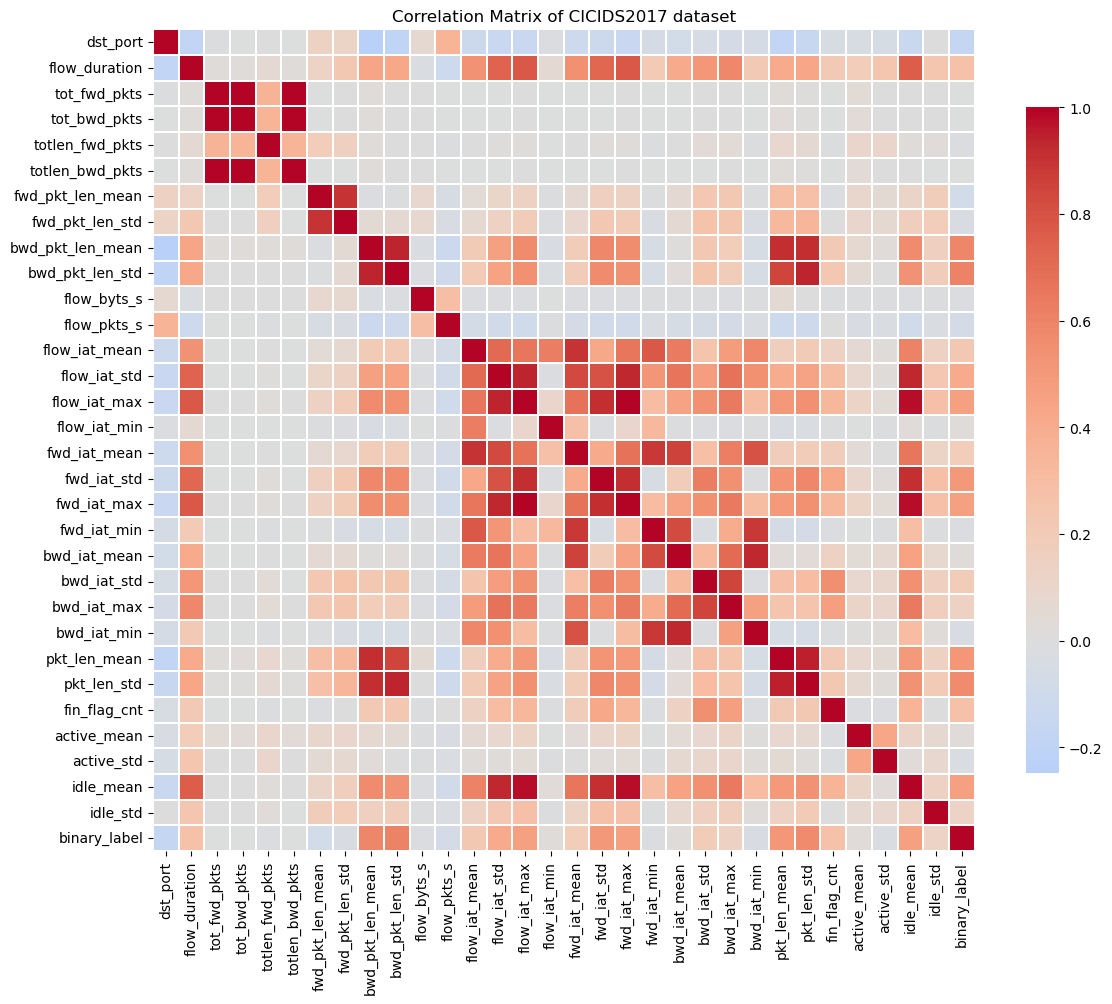

In [19]:
# Exclude target columns
corr_df = train_df.drop(
    columns=["label", "multi_label"], #using binary_label instead of label since it has been mapped to numeric data type.
    errors="ignore"
)

# Keep only numeric columns
corr_df = corr_df.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = corr_df.corr()

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of CICIDS2017 dataset", fontsize=12)
plt.tight_layout()
plt.show()

##### Skewness Graph of CICIDS2017


Total Features: 31
Need Transformation: 31
['totlen_fwd_pkts', 'tot_bwd_pkts', 'tot_fwd_pkts', 'totlen_bwd_pkts', 'flow_byts_s', 'active_std', 'active_mean', 'flow_iat_min', 'fwd_pkt_len_std', 'idle_std', 'bwd_iat_min', 'fwd_iat_min', 'fwd_pkt_len_mean', 'flow_iat_mean', 'bwd_iat_mean', 'flow_pkts_s', 'fwd_iat_mean', 'bwd_iat_std', 'fin_flag_cnt', 'bwd_iat_max', 'flow_iat_std', 'bwd_pkt_len_std', 'fwd_iat_std', 'idle_mean', 'fwd_iat_max', 'flow_iat_max', 'pkt_len_std', 'bwd_pkt_len_mean', 'pkt_len_mean', 'dst_port', 'flow_duration']


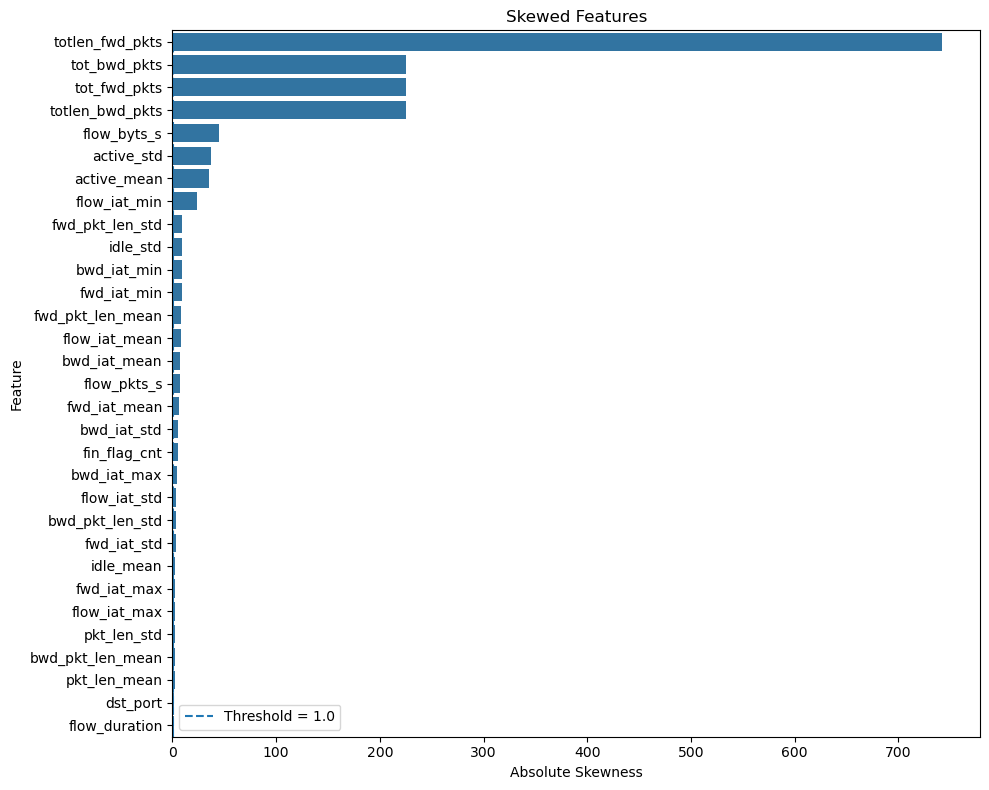

In [20]:
#Use numeric features only
num_df = (
    train_df
    .drop(columns=["label", "multi_label"], errors="ignore")
    .select_dtypes(include=np.number)
)

#exclude binary_label
num_df = num_df.drop(columns=["binary_label"], errors="ignore")

#Calculate Skewness
skewness = num_df.skew()

skew_df = pd.DataFrame({
    "feature": skewness.index,
    "skewness": skewness.values,
    "abs_skewness": skewness.abs().values
})

skew_df = skew_df.sort_values(
    "abs_skewness",
    ascending=False
)

#Features that require transformation
threshold = 1.0

transform_features = skew_df[
    skew_df["abs_skewness"] > threshold
]

print(f"\nTotal Features: {len(skew_df)}")
print(f"Need Transformation: {len(transform_features)}")

features_to_transform = transform_features["feature"].tolist()

print(features_to_transform)

#Skewness Plot
plt.figure(figsize=(10, 8))

sns.barplot(
    data=skew_df,
    x="abs_skewness",
    y="feature"
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.title("Skewed Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")
plt.legend()

plt.tight_layout()
plt.show()

Most of the features of CICIDS2017 dataset are skewed with few containing extreme outliers as seen on the graph above.They need transformation before training. We will use RobustScaler as it uses Median to handle outliers instead of normal Scaler which uses Mean. Also the target column 'label'/'binary_label' is highly imbalanced, so we will use SMOTE to oversample the minority class as it creates synthetic samples.

#### Internal Evaluation of Supervised Learning Models on CICIDS2017 dataset

##### Phase 1: Target -> binary_label

Training the Supervised Learning Models
1. Random Forest
2. XG Boost
3. Deep Neural Network

Binary Labels:   
1. 0 → Benign
2. 1 → Attack

In [21]:
DROP_COLS = ['label', 'binary_label', 'multi_label']

X = train_df.drop(columns=DROP_COLS).values.astype(np.float32)
y = train_df['binary_label'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          #to preserve class imbalance ratio 
)

print("Train split shape of binary labels :", X_tr.shape)
print("Test split shape of binary labels :", X_val.shape)
print()
print("Train class dist of binary labels  →  Benign:", np.sum(y_tr == 0),
      " | Attack:", np.sum(y_tr == 1))
print("Test class dist  of binary labels →  Benign:", np.sum(y_val == 0),
      " | Attack:", np.sum(y_val == 1))

Train split shape of binary labels : (1916704, 31)
Test split shape of binary labels : (479177, 31)

Train class dist of binary labels  →  Benign: 1576794  | Attack: 339910
Test class dist  of binary labels →  Benign: 394199  | Attack: 84978


##### Scaling and Oversampling
1. Scaling using RobostScaler
2. Oversampling using SMOTE

In [22]:
#Scaling
scaler_phase1 = RobustScaler()
X_tr_scaled   = scaler_phase1.fit_transform(X_tr)   # fit + transform
X_val_scaled  = scaler_phase1.transform(X_val)       # transform only

del X_tr, X_val, X
gc.collect()

#SMOTE
print("Class distribution of CICIDS2017 before SMOTE:", np.bincount(y_tr))

sm = SMOTE(random_state=42)
X_tr_res, y_tr_res = sm.fit_resample(X_tr_scaled, y_tr)

print("Class distribution of CICIDS2017 after SMOTE:", np.bincount(y_tr_res))

del X_tr_scaled
gc.collect()

Class distribution of CICIDS2017 before SMOTE: [1576794  339910]
Class distribution of CICIDS2017 after SMOTE: [1576794 1576794]


9332

##### Function to evaluate the models for binary labels

In [23]:
def evaluate_model(name, model, X_test, y_test, dataset_name, is_keras=False):

    if is_keras:
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_bin  = f1_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)

    print(f"  {name}  →  {dataset_name}")
    print(f"{'='*55}")
    print(f"  F1 (macro)  : {f1_mac:.4f}")
    print(f"  F1 (binary) : {f1_bin:.4f}")
    print(f"  ROC-AUC     : {auc:.4f}")
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=['Benign', 'Attack']
    ))

    # Confusion matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(cmap='Blues')
    plt.title(f"{name} — {dataset_name}")
    plt.tight_layout()
    plt.show()

    return {
        'model'    : name,
        'dataset'  : dataset_name,
        'f1_macro' : round(f1_mac, 4),
        'f1_binary': round(f1_bin, 4),
        'roc_auc'  : round(auc,    4)
    }

##### Training Random Forest

Phase 1 - Training Random Forest.....
Phase 1 - Random Forest training complete.
  Random Forest  →  CICIDS2017
  F1 (macro)  : 0.9955
  F1 (binary) : 0.9926
  ROC-AUC     : 0.9994

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    394199
      Attack       0.99      0.99      0.99     84978

    accuracy                           1.00    479177
   macro avg       0.99      1.00      1.00    479177
weighted avg       1.00      1.00      1.00    479177



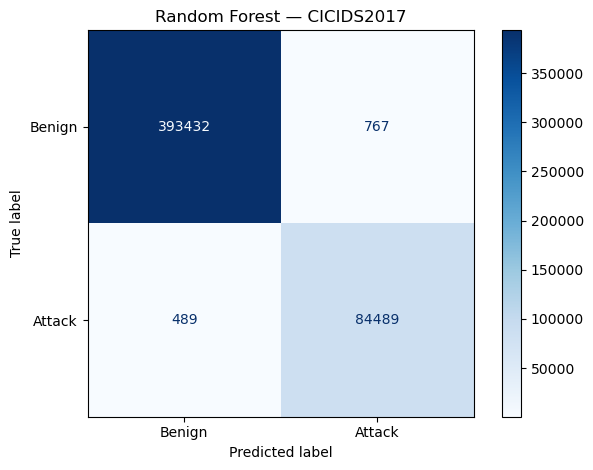

In [24]:
print("Phase 1 - Training Random Forest.....")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',   # second layer of imbalance protection
    n_jobs=-1,
    random_state=42
)

rf.fit(X_tr_res, y_tr_res)

print("Phase 1 - Random Forest training complete.")

# Evaluate on internal validation set
rf_val = evaluate_model(
    "Random Forest", rf,
    X_val_scaled, y_val,
    "CICIDS2017"
)

##### Training XGBoost

Phase 1 - Training XGBoost....
[0]	validation_0-logloss:0.60910
[50]	validation_0-logloss:0.02010
[100]	validation_0-logloss:0.01006
[150]	validation_0-logloss:0.00789
[200]	validation_0-logloss:0.00703
[250]	validation_0-logloss:0.00661
[299]	validation_0-logloss:0.00640
  XGBoost  →  CICIDS2017
  F1 (macro)  : 0.9965
  F1 (binary) : 0.9943
  ROC-AUC     : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    394199
      Attack       0.99      1.00      0.99     84978

    accuracy                           1.00    479177
   macro avg       1.00      1.00      1.00    479177
weighted avg       1.00      1.00      1.00    479177



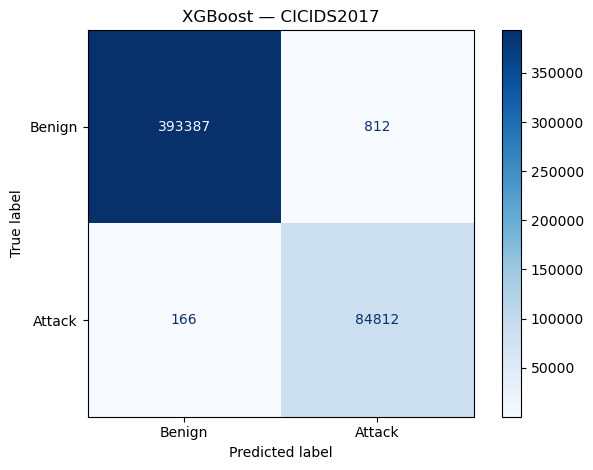

In [25]:
# scale_pos_weight = neg / pos — handles residual imbalance after SMOTE
neg = int(np.sum(y_tr_res == 0))
pos = int(np.sum(y_tr_res == 1))
spw = neg / pos

print(f"Phase 1 - Training XGBoost....")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    eval_metric='logloss',
    tree_method='hist',        #histogram-based training
    n_jobs=-1,
    random_state=42
)

xgb.fit(
    X_tr_res, y_tr_res,
    eval_set=[(X_val_scaled, y_val)],
    verbose=50
)

# Evaluate on internal validation set
xgb_val = evaluate_model(
    "XGBoost", xgb,
    X_val_scaled, y_val,
    "CICIDS2017"
)

##### Training Deep Neural Network


4 hidden layers (512 → 256 → 128 → 64) with:

- Batch Normalisation to stabilize traing across layers
- Dropout — prevents overfitting to CICIDS2017-specific patterns
- L2 regularisation to penalize large weights
- EarlyStopping on val_auc  for imbalanced data
- ReduceLROnPlateau to reduce learning rate when val_loss plateaus

In [26]:
#Class weights for the loss function
cw_vals      = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y_tr_res
)
class_weights = {0: cw_vals[0], 1: cw_vals[1]}
print("Class weights:", class_weights)

n_features = X_tr_res.shape[1]
print("Number of features:", n_features)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Number of features: 31


In [27]:
# DNN architecture
def build_dnn(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Layer 1
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Layer 2
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Layer 3
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Layer 4
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return model


dnn = build_dnn(n_features)
dnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,513 (752.00 KB)

 Trainable params: 190,721 (745.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [28]:
#Callbacks 
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',          # AUC more reliable than loss for imbalanced data
        patience=5,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

#Train 
print("Phase 1- Training Deep Neural Network for CICIDS2017")

history = dnn.fit(
    X_tr_res, y_tr_res,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=4096,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("Phase 1 - DNN training complete.")

Phase 1- Training Deep Neural Network for CICIDS2017
Epoch 1/40
770/770 ━━━━━━━━━━━━━━━━━━━━ 78s 86ms/step - accuracy: 0.8613 - auc: 0.9321 - loss: 0.3527 - precision: 0.8843 - recall: 0.8267 - val_accuracy: 0.3954 - val_auc: 0.8674 - val_loss: 1.6043 - val_precision: 0.2250 - val_recall: 0.9854 - learning_rate: 0.0010
Epoch 2/40
770/770 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.9631 - auc: 0.9910 - loss: 0.1348 - precision: 0.9663 - recall: 0.9596 - val_accuracy: 0.8509 - val_auc: 0.9726 - val_loss: 0.3622 - val_precision: 0.5443 - val_recall: 0.9765 - learning_rate: 0.0010
Epoch 3/40
770/770 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.9685 - auc: 0.9929 - loss: 0.1116 - precision: 0.9695 - recall: 0.9674 - val_accuracy: 0.8854 - val_auc: 0.9676 - val_loss: 0.3210 - val_precision: 0.6193 - val_recall: 0.9181 - learning_rate: 0.0010
Epoch 4/40
770/770 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.9699 - auc: 0.9933 - loss: 0.1061 - precision: 0.9699 - recall: 0.9699 - va

  Deep Neural Network  →  CICIDS2017
  F1 (macro)  : 0.9589
  F1 (binary) : 0.9324
  ROC-AUC     : 0.9943

              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99    394199
      Attack       0.93      0.94      0.93     84978

    accuracy                           0.98    479177
   macro avg       0.96      0.96      0.96    479177
weighted avg       0.98      0.98      0.98    479177



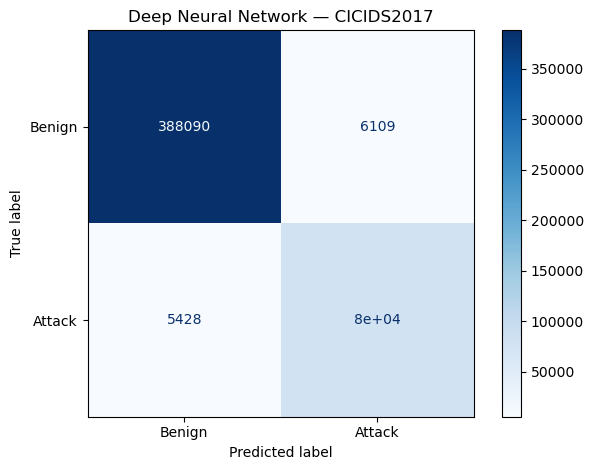

In [29]:
#Evaluate on internal CICIDS2017 test set
dnn_val = evaluate_model(
    "Deep Neural Network", dnn,
    X_val_scaled, y_val,
    "CICIDS2017",
    is_keras=True
)

##### Evaluation Graphs of DNN

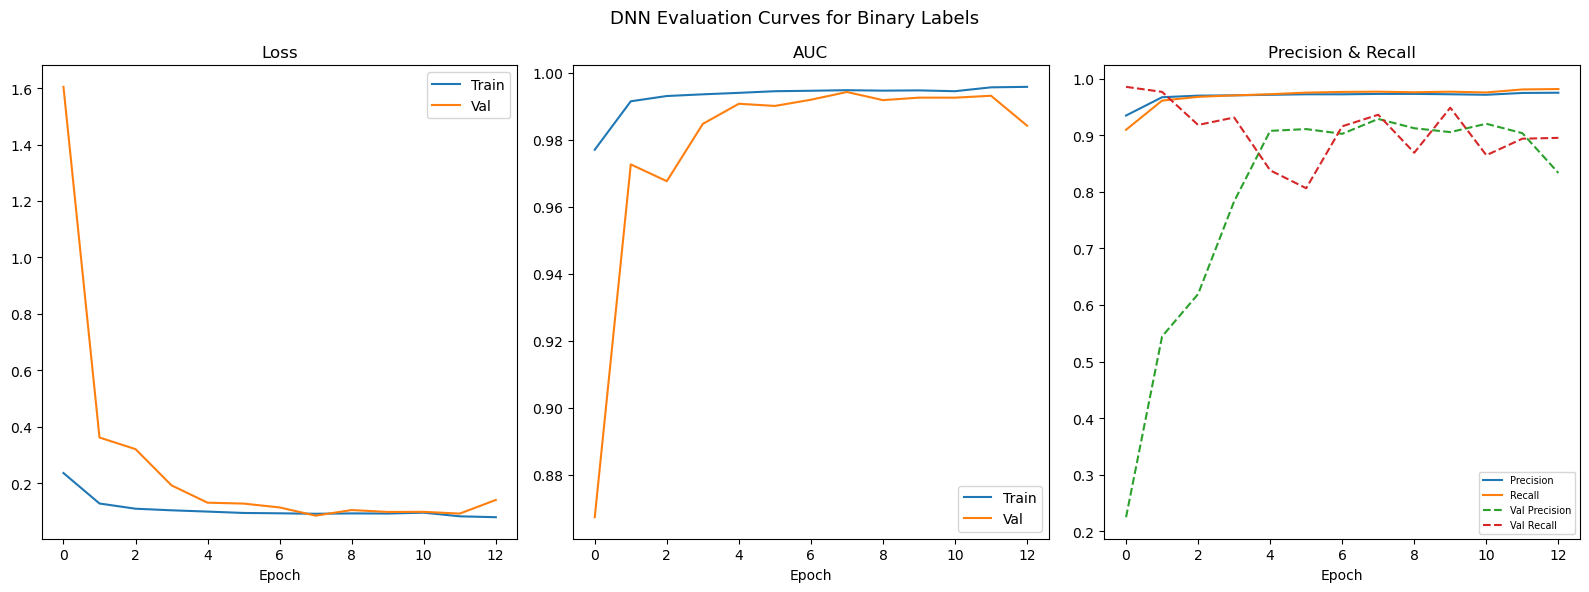

In [30]:
#Graphs
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'],      label='Train')
axes[1].plot(history.history['val_auc'],  label='Val')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['precision'],     label='Precision')
axes[2].plot(history.history['recall'],        label='Recall')
axes[2].plot(history.history['val_precision'],  label='Val Precision', linestyle='--')
axes[2].plot(history.history['val_recall'],     label='Val Recall',    linestyle='--')
axes[2].set_title('Precision & Recall')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=7)

plt.suptitle('DNN Evaluation Curves for Binary Labels', fontsize=13)
plt.tight_layout()
plt.show()

##### Phase1- Model Comparision using Graphs

  PHASE 1 — Evaluation Metrics of all Models
              model    dataset  f1_macro  f1_binary  roc_auc
      Random Forest CICIDS2017    0.9955     0.9926   0.9994
            XGBoost CICIDS2017    0.9965     0.9943   1.0000
Deep Neural Network CICIDS2017    0.9589     0.9324   0.9943


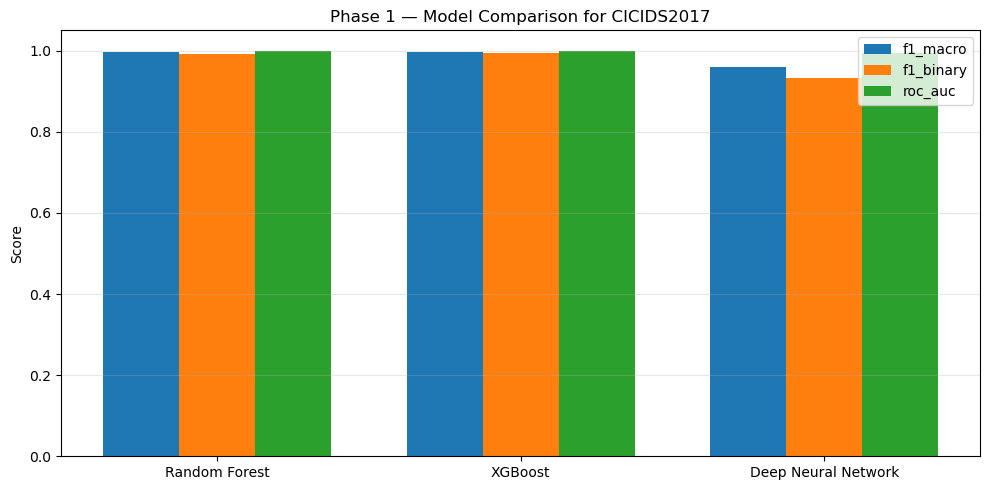

In [31]:
phase1_results = pd.DataFrame([rf_val, xgb_val, dnn_val])

print("  PHASE 1 — Evaluation Metrics of all Models")
print(phase1_results.to_string(index=False))

# Bar chart comparison
metrics = ['f1_macro', 'f1_binary', 'roc_auc']
x       = np.arange(len(phase1_results))
width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width,
           phase1_results[metric],
           width,
           label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(phase1_results['model'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Phase 1 — Model Comparison for CICIDS2017')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### ROC Curve & Precision-Recall Curve for all models

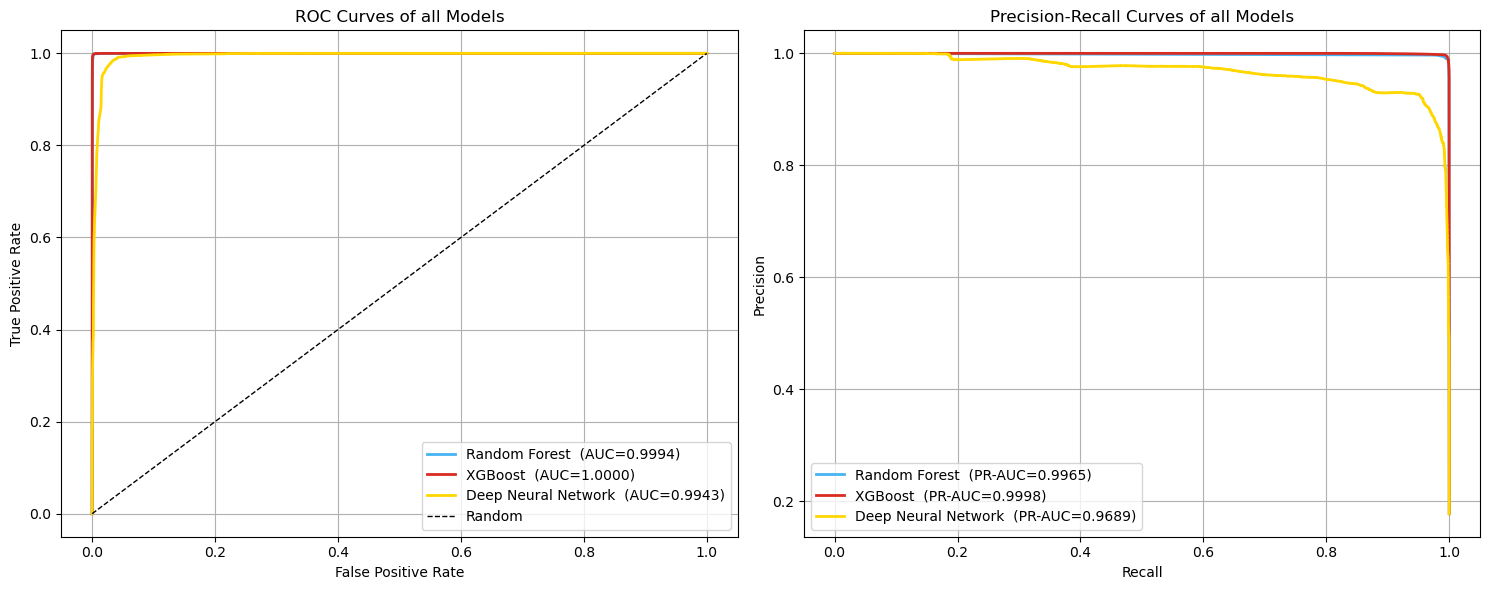

In [34]:
# predicted probabilities
def get_probs(model, X, is_keras=False):
    if is_keras:
        return model.predict(X, verbose=0).ravel()
    return model.predict_proba(X)[:, 1]

rf_probs  = get_probs(rf,  X_val_scaled)
xgb_probs = get_probs(xgb, X_val_scaled)
dnn_probs = get_probs(dnn, X_val_scaled, is_keras=True)

model_probs = {
    'Random Forest'      : rf_probs,
    'XGBoost'            : xgb_probs,
    'Deep Neural Network': dnn_probs,
}

colors = {
    'Random Forest'      : '#46B3F3',
    'XGBoost'            : '#D82C20',
    'Deep Neural Network': '#FFD700',
}
#Plot ROC + PR Curve side by side

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_name, probs in model_probs.items():
    fpr, tpr, _           = roc_curve(y_val, probs)
    roc_auc               = auc(fpr, tpr)
    precision, recall, _  = precision_recall_curve(y_val, probs)
    pr_auc                = average_precision_score(y_val, probs)

    axes[0].plot(fpr, tpr,
                 label=f'{model_name}  (AUC={roc_auc:.4f})',
                 color=colors[model_name], linewidth=2)
    axes[1].plot(recall, precision,
                 label=f'{model_name}  (PR-AUC={pr_auc:.4f})',
                 color=colors[model_name], linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves of all Models')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves of all Models')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=1)

plt.tight_layout()
plt.show()


From the graphs, it is seen that all models performed better at identifying attacks (binary_labels); F1 Score (F1 Binary)>0.9 when trained and tested on CICIDS2017 dataset. The best being XGBoost outperforming other models in all evaluation metrics.

#### Saving the trained models

In [35]:
import joblib

#Random Forest
joblib.dump(rf, "rf_model.pkl")

#XGBoost
joblib.dump(xgb, "xgb_model.pkl")

#RobustScaler
joblib.dump(scaler_phase1, "scaler_phase1.pkl")

#DNN
dnn.save("dnn_model.keras")

print("All Models for binary-labels saved successfully....")

All Models for binary-labels saved successfully....


##### Load the saved models if necessary.


##### Load Random Forest
rf = joblib.load("rf_model.pkl")

##### Load XGBoost
xgb = joblib.load("xgb_model.pkl")

##### Load scaler
scaler_phase1 = joblib.load("scaler_phase1.pkl")

##### Load DNN
dnn = keras.models.load_model("dnn_model.keras")

print("Models for binary-labels loaded successfully.")    

##### Verifying Loaded Models
print(type(rf))

print(type(xgb))

print(type(scaler_phase1))

print(type(dnn))

#### Cross dataset Generalization

For cross-dataset generalization we will evaluate the performance of the models already trained on CICIDS2017 dataset by testing on CSE-CIC-IDS2018 and UNSW-NB15 datasets.

##### Testing on CSE-CIC-IDS2018

In [36]:
#Features selection
X_test1 = test1_df.drop(
    columns=["label", "binary_label", "multi_label"]
).values.astype(np.float32)

#target
y_test1 = test1_df["binary_label"].values

#Using the same scalar for transforming the CSE-CIC-IDS2018 test dataset. 
X_test1_scaled = scaler_phase1.transform(X_test1)

##### Training Random Forest for binary-labels of CSE-CIC-IDS2018

Training Random Forest for binary-labels of CSE-CIC-IDS2018 .....
  Random Forest for binary-labels   →  CSE-CIC-IDS2018
  F1 (macro)  : 0.6468
  F1 (binary) : 0.3572
  ROC-AUC     : 0.8010

              precision    recall  f1-score   support

      Benign       0.90      0.97      0.94   9634903
      Attack       0.56      0.26      0.36   1349315

    accuracy                           0.88  10984218
   macro avg       0.73      0.62      0.65  10984218
weighted avg       0.86      0.88      0.87  10984218



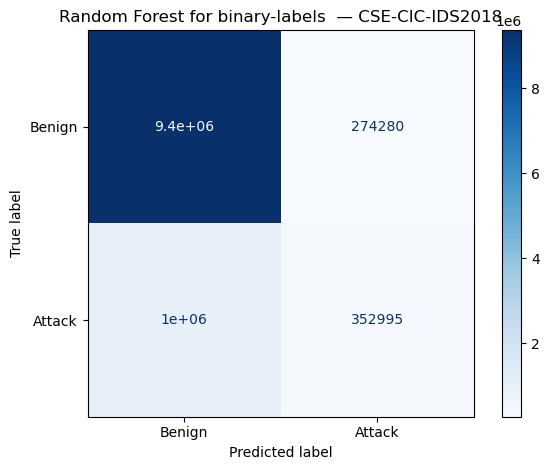

In [37]:
print("Training Random Forest for binary-labels of CSE-CIC-IDS2018 .....")
rf_test1 = evaluate_model("Random Forest for binary-labels ", rf, X_test1_scaled, y_test1, "CSE-CIC-IDS2018")

##### Training XGBoost for for binary-labels of CSE-CIC-IDS2018

Training XGBoost for binary-labels of CSE-CIC-IDS2018.....
  XGBoost for binary-labels   →  CSE-CIC-IDS2018
  F1 (macro)  : 0.7335
  F1 (binary) : 0.5118
  ROC-AUC     : 0.8699

              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96   9634903
      Attack       0.95      0.35      0.51   1349315

    accuracy                           0.92  10984218
   macro avg       0.93      0.67      0.73  10984218
weighted avg       0.92      0.92      0.90  10984218



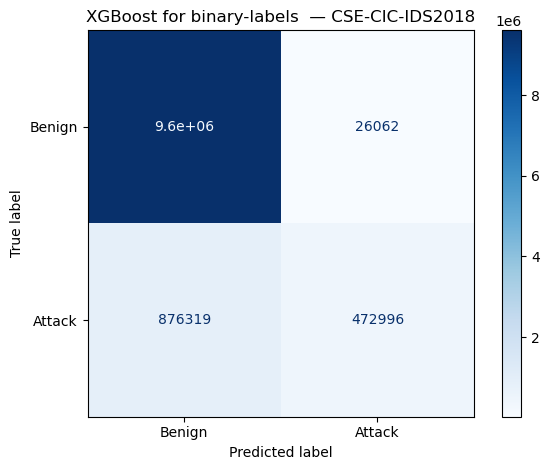

In [38]:
print("Training XGBoost for binary-labels of CSE-CIC-IDS2018.....")
xgb_test1 = evaluate_model("XGBoost for binary-labels ", xgb, X_test1_scaled, y_test1, "CSE-CIC-IDS2018")

##### Training DNN for binary-labels of CSE-CIC-IDS2018

Training Deep Neural Network for binary-labels of CSE-CIC-IDS2018
  DNN for binary-labels   →  CSE-CIC-IDS2018
  F1 (macro)  : 0.5895
  F1 (binary) : 0.2607
  ROC-AUC     : 0.6064

              precision    recall  f1-score   support

      Benign       0.90      0.94      0.92   9634903
      Attack       0.34      0.21      0.26   1349315

    accuracy                           0.85  10984218
   macro avg       0.62      0.58      0.59  10984218
weighted avg       0.83      0.85      0.84  10984218



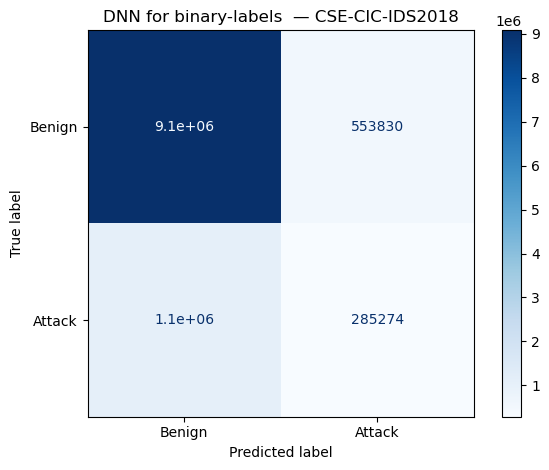

In [39]:
print("Training Deep Neural Network for binary-labels of CSE-CIC-IDS2018")
dnn_test1 = evaluate_model("DNN for binary-labels ", dnn, X_test1_scaled, y_test1, "CSE-CIC-IDS2018", is_keras=True)

##### Model Comparision for CSE-CIC-IDS2018

In [40]:
#Comparing models on the basis of F1 score

cd_result1 = pd.DataFrame([rf_test1, xgb_test1, dnn_test1])
# print(cd_result1.columns.tolist())
cd_result1.sort_values(by=["f1_binary", "roc_auc"], ascending=False)

,model,dataset,f1_macro,f1_binary,roc_auc
1,XGBoost for binary-labels,CSE-CIC-IDS2018,0.7335,0.5118,0.8699
0,Random Forest for binary-labels,CSE-CIC-IDS2018,0.6468,0.3572,0.8010
2,DNN for binary-labels,CSE-CIC-IDS2018,0.5895,0.2607,0.6064


From the output above, we can see that for NIDS cross-dataset generalization on an unseen dataset CSE-CIC-IDS2018, XGBoost seems to perform better than Random Forest and DNN with F1 Score of 0.51 and ROC-AUC value of 0.86. Random Forest and DNN shows substantial degradation in performance. Although all the models are significant in detecting 'Benign', they struggle to detect the 'Attack'. XGBoost with Precision of 0.95 and Recall of 0.35 outperforms other models. Conclusively, considering low F1 Score, the models struggles to identify attacks in an unseen dataset.

##### Testing on UNSW-NB15

In [41]:
#Features selection
X_test2 = test2_df.drop(
    columns=["label", "binary_label", "multi_label"]
).values.astype(np.float32)

#target
y_test2 = test2_df["binary_label"].values

#Using the same scalar for transforming the UNSW-NB15 test dataset. 
X_test2_scaled = scaler_phase1.transform(X_test2)

##### Training Random Forest for binary-labels of UNSW-NB15

Training Random Forest for binary-labels of UNSW-NB15 .....
  Random Forest for binary-labels   →  UNSW-NB15
  F1 (macro)  : 0.4946
  F1 (binary) : 0.0053
  ROC-AUC     : 0.7356

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98   2488894
      Attack       0.49      0.00      0.01     81489

    accuracy                           0.97   2570383
   macro avg       0.73      0.50      0.49   2570383
weighted avg       0.95      0.97      0.95   2570383



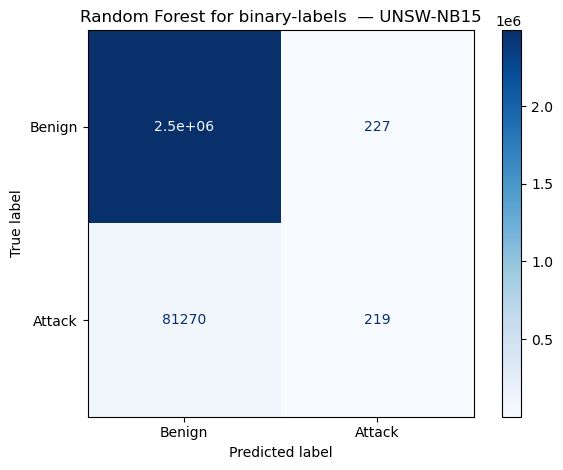

In [42]:
print("Training Random Forest for binary-labels of UNSW-NB15 .....")
rf_test2 = evaluate_model("Random Forest for binary-labels ", rf, X_test2_scaled, y_test2, "UNSW-NB15")

##### Training XGBoost for for binary-labels of UNSW-NB15

Training XGBoost for binary-labels of UNSW-NB15.....
  XGBoost for binary-labels   →  UNSW-NB15
  F1 (macro)  : 0.5639
  F1 (binary) : 0.1431
  ROC-AUC     : 0.8549

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98   2488894
      Attack       0.78      0.08      0.14     81489

    accuracy                           0.97   2570383
   macro avg       0.88      0.54      0.56   2570383
weighted avg       0.96      0.97      0.96   2570383



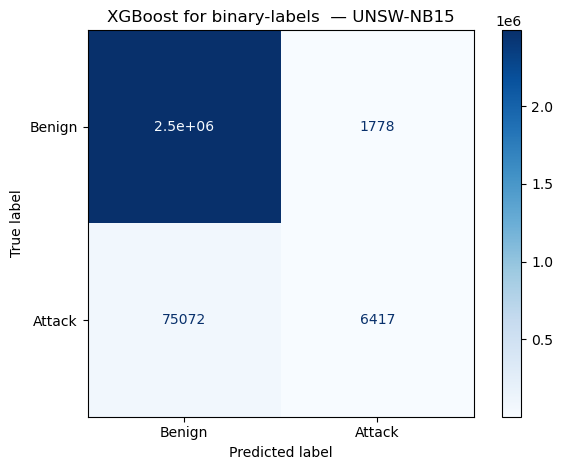

In [43]:
print("Training XGBoost for binary-labels of UNSW-NB15.....")
xgb_test2 = evaluate_model("XGBoost for binary-labels ", xgb, X_test2_scaled, y_test2, "UNSW-NB15")

##### Training DNN for binary-labels of UNSW-NB15

Training Deep Neural Network for binary-labels of UNSW-NB15
  DNN for binary-labels   →  UNSW-NB15
  F1 (macro)  : 0.6741
  F1 (binary) : 0.3668
  ROC-AUC     : 0.8820

              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98   2488894
      Attack       0.41      0.33      0.37     81489

    accuracy                           0.96   2570383
   macro avg       0.70      0.66      0.67   2570383
weighted avg       0.96      0.96      0.96   2570383



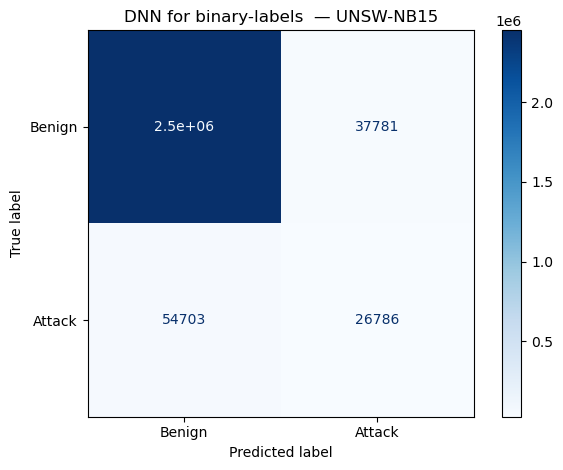

In [46]:
print("Training Deep Neural Network for binary-labels of UNSW-NB15")
dnn_test2 = evaluate_model("DNN for binary-labels ", dnn, X_test2_scaled, y_test2, "UNSW-NB15", is_keras=True)

##### Model Comparision for UNSW-NB15

In [48]:
#Comparing models on the basis of F1 score

cd_result2 = pd.DataFrame([rf_test2, xgb_test2, dnn_test2])
cd_result2.sort_values(by=["f1_binary", "roc_auc"], ascending=False)

,model,dataset,f1_macro,f1_binary,roc_auc
2,DNN for binary-labels,UNSW-NB15,0.6741,0.3668,0.8820
1,XGBoost for binary-labels,UNSW-NB15,0.5639,0.1431,0.8549
0,Random Forest for binary-labels,UNSW-NB15,0.4946,0.0053,0.7356


For UNSW-NB15 dataset, DNN with F1 Score of 0.3914 ROC-AUC Score 0.86 turned out to be the most significant among all the models. In comparision to other datasets, UNSW-NB15 has significantly less number of attacks 81489 and less attack labels which could be the determining factor for the model performance.

- Infiltration      60540
- PortScan          12035
- DoS                8914

Conclusively, for Network Intrusion Detection System, based on the performance and overall metrics evaluation, XGBoost has upperhand in identifying risks (binary).